ADVANCED NEUTRON TRANSPORT MONTE CARLO SIMULATION
Reactor size: 20.0 x 20.0 cm
Fission spectrum temperature: 1.29 MeV
Thermal cutoff: 0.62 eV
Boundary condition: vacuum
nu_bar (U-235): 2.43

Simulating 10000 neutron histories...
  Progress: 0/10000
  Progress: 200/10000
  Progress: 400/10000
  Progress: 600/10000
  Progress: 800/10000
  Progress: 1000/10000
  Progress: 1200/10000
  Progress: 1400/10000
  Progress: 1600/10000
  Progress: 1800/10000
  Progress: 2000/10000
  Progress: 2200/10000
  Progress: 2400/10000
  Progress: 2600/10000
  Progress: 2800/10000
  Progress: 3000/10000
  Progress: 3200/10000
  Progress: 3400/10000
  Progress: 3600/10000
  Progress: 3800/10000
  Progress: 4000/10000
  Progress: 4200/10000
  Progress: 4400/10000
  Progress: 4600/10000
  Progress: 4800/10000
  Progress: 5000/10000
  Progress: 5200/10000
  Progress: 5400/10000
  Progress: 5600/10000
  Progress: 5800/10000
  Progress: 6000/10000
  Progress: 6200/10000
  Progress: 6400/10000
  Progress: 6600/10

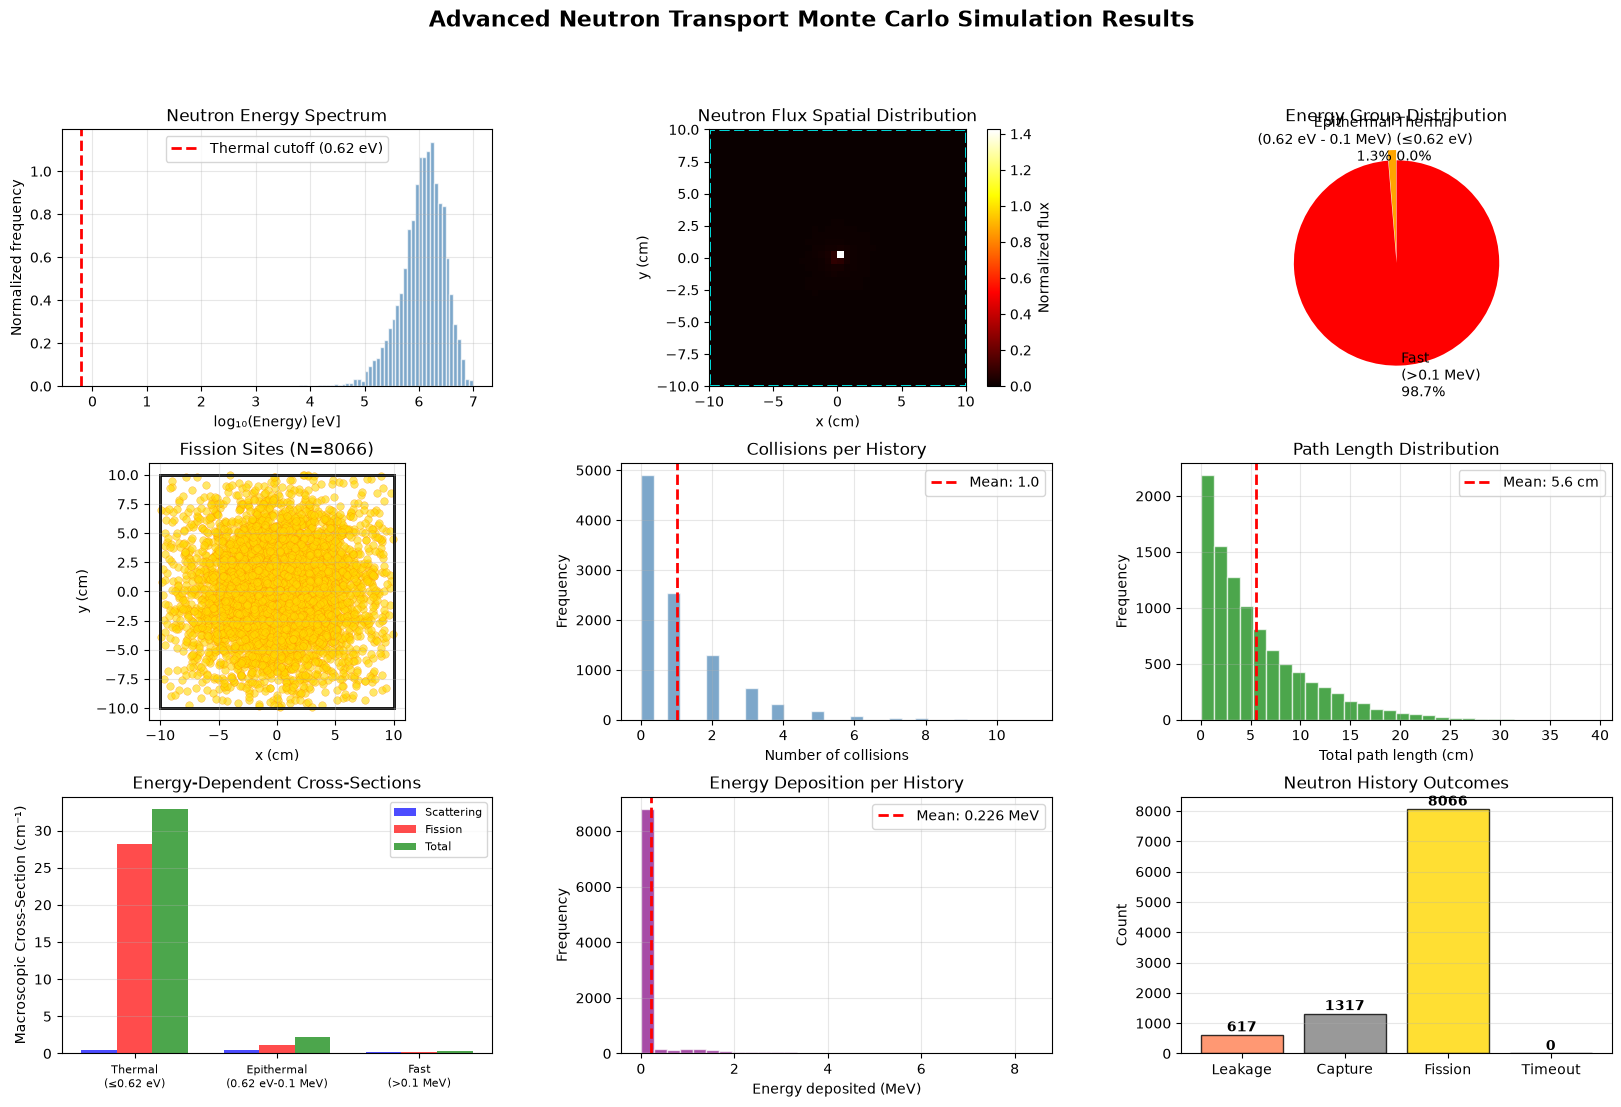


Figure saved: advanced_neutron_transport.png

SAMPLE NEUTRON TRAJECTORY
Outcome: fission
Birth energy: 581480.37 eV
Final energy: 581480.37 eV
Number of collisions: 0
Scatters: 0
Path length: 3.24 cm
Energy deposited: 0.0000 MeV

Collision history:
  1. Pos=(0.39, 3.22), E=581480.37 eV, Reaction=fission


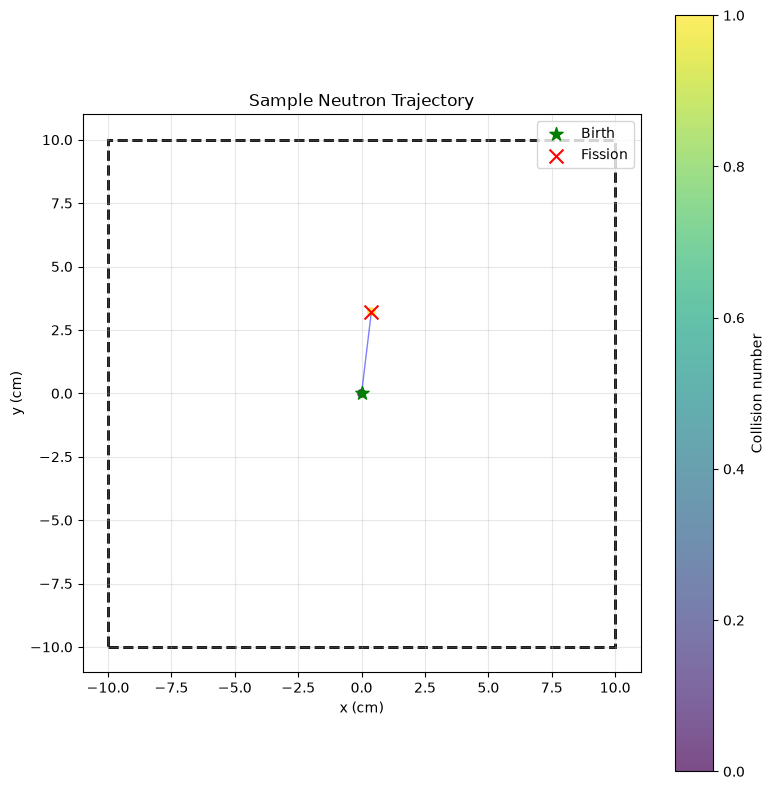

Figure saved: sample_neutron_trajectory.png


In [2]:
# ============================================================
# Advanced Neutron Transport Monte Carlo Simulation
# ============================================================
#
# Features:
# - Energy-dependent cross-sections (thermal, epithermal, fast)
# - Maxwell-Boltzmann fission spectrum
# - Proper free-path sampling from exponential distribution
# - Energy-dependent scattering physics:
#   * Isotropic in CM frame for thermal neutrons
#   * Forward-peaked for fast neutrons
# - Multi-group energy tracking
# - Reflective/absorbing boundary conditions
# - Thermal cutoff at 0.62 eV
# - Detailed reaction type tracking
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.special import erf
from matplotlib.gridspec import GridSpec
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

# ============================================================
# PHYSICS PARAMETERS
# ============================================================

# Energy group boundaries (in MeV)
# Thermal: 0 - 0.62 eV (6.2e-7 MeV)
# Epithermal: 0.62 eV - 0.1 MeV
# Fast: 0.1 MeV - 10 MeV
E_thermal_cutoff = 6.2e-7  # 0.62 eV in MeV
E_epithermal_max = 0.1      # MeV
E_fast_max = 10.0           # MeV

# U-235 cross-sections (microscopic, in barns) for different energy groups
# Values are approximate averages for each group
cross_sections = {
    'thermal': {
        'sigma_total': 680.9,    # barns
        'sigma_scatter': 10.5,
        'sigma_absorb': 98.3,
        'sigma_fission': 582.6,
        'sigma_capture': 98.3,   # radiative capture
    },
    'epithermal': {
        'sigma_total': 45.0,
        'sigma_scatter': 10.0,
        'sigma_absorb': 10.0,
        'sigma_fission': 25.0,
        'sigma_capture': 10.0,
    },
    'fast': {
        'sigma_total': 7.5,
        'sigma_scatter': 4.0,
        'sigma_absorb': 0.5,
        'sigma_fission': 3.0,
        'sigma_capture': 0.5,
    }
}

# Material properties
N_U235 = 0.0483  # Number density of U-235 (atoms/barn-cm) for typical reactor fuel
# Macroscopic cross-sections: Sigma = N * sigma
for group in cross_sections:
    for key in cross_sections[group]:
        cross_sections[group][key] *= N_U235  # Convert to cm^-1

# Reactor geometry
reactor_width = 20.0    # cm (2D square reactor)
reactor_height = 20.0   # cm
x_center, y_center = 0.0, 0.0

# Boundary condition type: 'vacuum' (leaking) or 'reflective'
boundary_condition = 'vacuum'

# Average number of neutrons per fission (U-235, thermal)
nu_bar = 2.43

# Maxwell-Boltzmann fission spectrum parameters
# f(E) = (2/sqrt(pi*T^3)) * sqrt(E) * exp(-E/T)
T_fission = 1.29  # MeV (effective temperature for U-235 fission spectrum)
E_max_birth = 10.0  # MeV (maximum birth energy)

# ============================================================
# PHYSICS FUNCTIONS
# ============================================================

def get_energy_group(energy):
    """Determine energy group based on neutron energy in MeV."""
    if energy <= E_thermal_cutoff:
        return 'thermal'
    elif energy <= E_epithermal_max:
        return 'epithermal'
    else:
        return 'fast'

def sample_fission_spectrum():
    """
    Sample neutron birth energy from Maxwell-Boltzmann fission spectrum.
    f(E) ~ sqrt(E) * exp(-E/T)
    Using acceptance-rejection method.
    """
    while True:
        # Sample from Maxwell-Boltzmann using transformation method
        # For Maxwell-Boltzmann: E = -T * ln(R1*R2*R3) where R are uniform random
        # Actually for f(E) ~ sqrt(E)*exp(-E/T):
        # Use gamma distribution: Gamma(3/2, T)
        # Sample using Marsaglia's method for gamma
        while True:
            # Generate candidate from approximate distribution
            d = 1.5  # shape parameter for gamma = 3/2
            c = 1.0  # scale factor
            
            # Marsaglia's rejection method for gamma distribution
            u = np.random.random()
            v = np.random.random()
            w = np.random.random()
            
            if u <= np.e / (np.e + d):
                x = v**(1/d)
                y = w * x**(d-1)
            else:
                x = 1 - np.log(v)
                y = w * np.exp(-x)
            
            if y <= x**(d-1) * np.exp(-x):
                energy = T_fission * x
                if energy <= E_max_birth:
                    return energy

def sample_free_path(macro_sigma_total):
    """
    Sample distance to next collision from exponential distribution.
    P(s) = Sigma_t * exp(-Sigma_t * s)
    Using inverse transform: s = -ln(1-R)/Sigma_t
    """
    R = np.random.random()
    # Add small epsilon to avoid log(0)
    R = max(R, 1e-10)
    return -np.log(R) / macro_sigma_total

def sample_scattering_angle(energy, target_mass=235):
    """
    Sample scattering angle based on neutron energy.
    
    For thermal neutrons: isotropic in center-of-mass (CM) frame
    For fast neutrons: forward-peaked in laboratory frame
    
    Returns: (mu_lab, mu_cm, E_after)
    where mu = cos(theta)
    """
    A = target_mass  # Atomic mass of target nucleus
    
    # Sample mu_cm (cosine of scattering angle in CM frame)
    if energy <= E_thermal_cutoff:
        # Thermal: isotropic in CM -> uniform in mu_cm
        mu_cm = 2.0 * np.random.random() - 1.0
    else:
        # Fast: forward-peaked in CM (p-wave scattering)
        # Use simple linear anisotropy: P(mu_cm) ~ 1 + 0.5*mu_cm
        while True:
            mu_cm = 2.0 * np.random.random() - 1.0
            if np.random.random() <= (1.0 + 0.5 * mu_cm) / 2.0:
                break
    
    # Transform from CM to lab frame
    # mu_lab = (1 + A*mu_cm) / sqrt(1 + A^2 + 2*A*mu_cm)
    denominator = np.sqrt(1 + A**2 + 2*A*mu_cm)
    mu_lab = (1 + A * mu_cm) / denominator
    
    # Energy after scattering
    # E'/E = (1 + A^2 + 2*A*mu_cm) / (A+1)^2
    alpha = ((A - 1) / (A + 1))**2
    E_ratio = (1 + alpha + (1 - alpha) * mu_cm) / 2.0
    E_after = energy * E_ratio
    
    return mu_lab, mu_cm, E_after

def sample_reaction_type(energy):
    """
    Determine reaction type at collision based on partial cross-sections.
    
    Returns: 'scatter', 'fission', 'capture', or 'elastic'
    """
    group = get_energy_group(energy)
    sigma = cross_sections[group]
    
    # Build cumulative probabilities
    reactions = ['scatter', 'fission', 'capture']
    probs = np.array([sigma['sigma_scatter'], 
                      sigma['sigma_fission'], 
                      sigma['sigma_capture']])
    probs /= probs.sum()
    cumsum = np.cumsum(probs)
    
    R = np.random.random()
    if R < cumsum[0]:
        return 'scatter'
    elif R < cumsum[1]:
        return 'fission'
    else:
        return 'capture'

def sample_direction_2d():
    """Sample random 2D direction vector."""
    angle = np.random.uniform(0, 2 * np.pi)
    return np.array([np.cos(angle), np.sin(angle)])

# ============================================================
# NEUTRON HISTORY SIMULATION
# ============================================================

class Neutron:
    """Class to store neutron state."""
    def __init__(self, x, y, energy, direction=None):
        self.x = x
        self.y = y
        self.energy = energy
        self.direction = direction if direction is not None else sample_direction_2d()
        self.alive = True
        self.history = [(x, y, energy)]  # Track entire history

def simulate_neutron_history(birth_x, birth_y, max_collisions=100):
    """
    Simulate complete neutron history with energy-dependent physics.
    
    Returns: 
        outcome: 'leakage', 'capture', 'timeout'
        neutron: final neutron state
        data: dictionary of tracked quantities
    """
    # Sample birth energy from fission spectrum
    birth_energy = sample_fission_spectrum()
    neutron = Neutron(birth_x, birth_y, birth_energy)
    
    data = {
        'collisions': 0,
        'scatters': 0,
        'fissions': 0,
        'total_path_length': 0.0,
        'energy_deposited': 0.0,
        'positions': [(birth_x, birth_y)],
        'energies': [birth_energy],
        'reactions': [],
    }
    
    for collision in range(max_collisions):
        data['collisions'] = collision
        
        # Get cross-sections for current energy
        group = get_energy_group(neutron.energy)
        sigma = cross_sections[group]
        
        # Sample distance to next collision
        distance = sample_free_path(sigma['sigma_total'])
        data['total_path_length'] += distance
        
        # Move neutron
        dx = neutron.direction[0] * distance
        dy = neutron.direction[1] * distance
        neutron.x += dx
        neutron.y += dy
        
        # Check boundaries
        if abs(neutron.x) > reactor_width/2 or abs(neutron.y) > reactor_height/2:
            # Find where it crossed the boundary
            # Simple check: if outside, it leaked
            return 'leakage', neutron, data
        
        # Record position
        data['positions'].append((neutron.x, neutron.y))
        data['energies'].append(neutron.energy)
        
        # Determine reaction type
        reaction = sample_reaction_type(neutron.energy)
        data['reactions'].append(reaction)
        
        if reaction == 'scatter':
            data['scatters'] += 1
            # Sample scattering angle and new energy
            mu_lab, mu_cm, E_new = sample_scattering_angle(neutron.energy)
            
            # Update neutron direction
            # Rotate current direction by scattering angle
            current_angle = np.arctan2(neutron.direction[1], neutron.direction[0])
            # Sample azimuthal angle (isotropic)
            phi = np.random.uniform(0, 2*np.pi)
            # New direction in spherical coordinates
            new_angle = current_angle + np.arccos(mu_lab)
            neutron.direction = np.array([np.cos(new_angle), np.sin(new_angle)])
            
            # Update energy
            energy_loss = neutron.energy - E_new
            data['energy_deposited'] += energy_loss
            neutron.energy = E_new
            
            # Check for thermal cutoff
            if neutron.energy <= E_thermal_cutoff and group != 'thermal':
                # Neutron reached thermal energies
                pass
                
        elif reaction == 'fission':
            data['fissions'] += 1
            neutron.alive = False
            
            # Generate fission neutrons
            n_fission_neutrons = np.random.poisson(nu_bar)
            fission_children = []
            
            for _ in range(max(0, n_fission_neutrons)):
                child_energy = sample_fission_spectrum()
                child_direction = sample_direction_2d()
                fission_children.append({
                    'x': neutron.x,
                    'y': neutron.y,
                    'energy': child_energy,
                    'direction': child_direction,
                })
            
            data['fission_children'] = fission_children
            return 'fission', neutron, data
            
        elif reaction == 'capture':
            # Neutron captured, history ends
            data['energy_deposited'] += neutron.energy
            return 'capture', neutron, data
    
    # Max collisions reached
    return 'timeout', neutron, data

# ============================================================
# RUN SIMULATION
# ============================================================

print("=" * 70)
print("ADVANCED NEUTRON TRANSPORT MONTE CARLO SIMULATION")
print("=" * 70)
print(f"Reactor size: {reactor_width} x {reactor_height} cm")
print(f"Fission spectrum temperature: {T_fission} MeV")
print(f"Thermal cutoff: {E_thermal_cutoff*1e6:.2f} eV")
print(f"Boundary condition: {boundary_condition}")
print(f"nu_bar (U-235): {nu_bar}")
print("=" * 70)

# Run multiple neutron histories
N_histories = 10000
all_results = {
    'leakage': 0,
    'capture': 0,
    'fission': 0,
    'timeout': 0,
}

all_data = []
all_energies = []
all_positions = []
fission_sites = []

print(f"\nSimulating {N_histories} neutron histories...")
for i in range(N_histories):
    if i % 200 == 0:
        print(f"  Progress: {i}/{N_histories}")
    
    outcome, neutron, data = simulate_neutron_history(x_center, y_center)
    all_results[outcome] += 1
    all_data.append(data)
    all_energies.extend(data['energies'])
    all_positions.extend(data['positions'])
    
    if outcome == 'fission':
        fission_sites.append((neutron.x, neutron.y))

# Calculate k_eff
neutrons_produced = all_results['fission'] * nu_bar
neutrons_lost = all_results['leakage'] + all_results['capture']
k_eff = neutrons_produced / neutrons_lost if neutrons_lost > 0 else np.inf

print("\n" + "=" * 70)
print("SIMULATION RESULTS")
print("=" * 70)
print(f"Total histories: {N_histories}")
print(f"\nOutcomes:")
print(f"  Leakage:   {all_results['leakage']:5d} ({all_results['leakage']/N_histories*100:5.1f}%)")
print(f"  Capture:   {all_results['capture']:5d} ({all_results['capture']/N_histories*100:5.1f}%)")
print(f"  Fission:   {all_results['fission']:5d} ({all_results['fission']/N_histories*100:5.1f}%)")
print(f"  Timeout:   {all_results['timeout']:5d} ({all_results['timeout']/N_histories*100:5.1f}%)")
print(f"\nk_eff = {k_eff:.4f}")
if k_eff > 1.0:
    print("  → SUPERCRITICAL")
elif abs(k_eff - 1.0) < 0.01:
    print("  → CRITICAL")
else:
    print("  → SUBCRITICAL")

# Average statistics
avg_collisions = np.mean([d['collisions'] for d in all_data])
avg_scatters = np.mean([d['scatters'] for d in all_data])
avg_path_length = np.mean([d['total_path_length'] for d in all_data])
avg_energy_dep = np.mean([d['energy_deposited'] for d in all_data])

print(f"\nAverage quantities per history:")
print(f"  Collisions:   {avg_collisions:.1f}")
print(f"  Scatters:     {avg_scatters:.1f}")
print(f"  Path length:  {avg_path_length:.2f} cm")
print(f"  Energy dep.:  {avg_energy_dep:.4f} MeV")
print("=" * 70)

# ============================================================
# VISUALIZATION
# ============================================================

fig = plt.figure(figsize=(20, 12))
gs = GridSpec(3, 3, figure=fig, hspace=0.3, wspace=0.3)

# 1. Energy spectrum (all neutrons)
ax1 = fig.add_subplot(gs[0, 0])
energies_mev = np.array(all_energies) * 1e6  # Convert to eV for display
ax1.hist(np.log10(energies_mev + 1e-10), bins=50, density=True, 
         color='steelblue', alpha=0.7, edgecolor='white')
ax1.axvline(np.log10(0.62), color='red', linestyle='--', linewidth=2, 
            label=f'Thermal cutoff (0.62 eV)')
ax1.set_xlabel('log₁₀(Energy) [eV]')
ax1.set_ylabel('Normalized frequency')
ax1.set_title('Neutron Energy Spectrum')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2. Spatial distribution (heatmap)
ax2 = fig.add_subplot(gs[0, 1])
pos_array = np.array(all_positions)
hist, xedges, yedges = np.histogram2d(
    pos_array[:, 0], pos_array[:, 1], bins=40,
    range=[[-reactor_width/2, reactor_width/2], 
           [-reactor_height/2, reactor_height/2]],
    density=True
)
im = ax2.imshow(hist.T, extent=[-reactor_width/2, reactor_width/2,
                                -reactor_height/2, reactor_height/2],
                origin='lower', cmap='hot', aspect='equal')
plt.colorbar(im, ax=ax2, label='Normalized flux')
# Draw reactor boundary
rect = plt.Rectangle((-reactor_width/2, -reactor_height/2), 
                     reactor_width, reactor_height,
                     linewidth=2, edgecolor='cyan', facecolor='none', 
                     linestyle='--')
ax2.add_patch(rect)
ax2.set_xlabel('x (cm)')
ax2.set_ylabel('y (cm)')
ax2.set_title('Neutron Flux Spatial Distribution')

# 3. Energy groups pie chart
ax3 = fig.add_subplot(gs[0, 2])
energies_mev_array = np.array(all_energies)
thermal_frac = np.sum(energies_mev_array <= E_thermal_cutoff) / len(energies_mev_array)
epithermal_frac = np.sum((energies_mev_array > E_thermal_cutoff) & 
                         (energies_mev_array <= E_epithermal_max)) / len(energies_mev_array)
fast_frac = np.sum(energies_mev_array > E_epithermal_max) / len(energies_mev_array)

sizes = [thermal_frac, epithermal_frac, fast_frac]
labels = [f'Thermal\n(≤0.62 eV)\n{thermal_frac*100:.1f}%',
          f'Epithermal\n(0.62 eV - 0.1 MeV)\n{epithermal_frac*100:.1f}%',
          f'Fast\n(>0.1 MeV)\n{fast_frac*100:.1f}%']
colors = ['blue', 'orange', 'red']
ax3.pie(sizes, labels=labels, colors=colors, autopct='',
        explode=(0.05, 0.05, 0.05), startangle=90)
ax3.set_title('Energy Group Distribution')

# 4. Fission sites
ax4 = fig.add_subplot(gs[1, 0])
if fission_sites:
    fiss_array = np.array(fission_sites)
    ax4.scatter(fiss_array[:, 0], fiss_array[:, 1], 
                c='gold', s=30, alpha=0.6, edgecolors='darkorange',
                linewidth=0.3)
rect4 = plt.Rectangle((-reactor_width/2, -reactor_height/2), 
                      reactor_width, reactor_height,
                      linewidth=2, edgecolor='black', facecolor='none')
ax4.add_patch(rect4)
ax4.set_xlabel('x (cm)')
ax4.set_ylabel('y (cm)')
ax4.set_title(f'Fission Sites (N={len(fission_sites)})')
ax4.set_aspect('equal')
ax4.grid(True, alpha=0.3)

# 5. Collision statistics
ax5 = fig.add_subplot(gs[1, 1])
collision_counts = [d['collisions'] for d in all_data]
ax5.hist(collision_counts, bins=30, color='steelblue', alpha=0.7, 
         edgecolor='white')
ax5.axvline(avg_collisions, color='red', linestyle='--', linewidth=2,
            label=f'Mean: {avg_collisions:.1f}')
ax5.set_xlabel('Number of collisions')
ax5.set_ylabel('Frequency')
ax5.set_title('Collisions per History')
ax5.legend()
ax5.grid(True, alpha=0.3)

# 6. Path length distribution
ax6 = fig.add_subplot(gs[1, 2])
path_lengths = [d['total_path_length'] for d in all_data]
ax6.hist(path_lengths, bins=30, color='green', alpha=0.7, edgecolor='white')
ax6.axvline(avg_path_length, color='red', linestyle='--', linewidth=2,
            label=f'Mean: {avg_path_length:.1f} cm')
ax6.set_xlabel('Total path length (cm)')
ax6.set_ylabel('Frequency')
ax6.set_title('Path Length Distribution')
ax6.legend()
ax6.grid(True, alpha=0.3)

# 7. Cross-section visualization
ax7 = fig.add_subplot(gs[2, 0])
groups = ['Thermal\n(≤0.62 eV)', 'Epithermal\n(0.62 eV-0.1 MeV)', 'Fast\n(>0.1 MeV)']
sigma_total = [cross_sections[g]['sigma_total'] for g in ['thermal', 'epithermal', 'fast']]
sigma_scatter = [cross_sections[g]['sigma_scatter'] for g in ['thermal', 'epithermal', 'fast']]
sigma_fission = [cross_sections[g]['sigma_fission'] for g in ['thermal', 'epithermal', 'fast']]

x_pos = np.arange(len(groups))
width = 0.25
ax7.bar(x_pos - width, sigma_scatter, width, label='Scattering', color='blue', alpha=0.7)
ax7.bar(x_pos, sigma_fission, width, label='Fission', color='red', alpha=0.7)
ax7.bar(x_pos + width, sigma_total, width, label='Total', color='green', alpha=0.7)
ax7.set_xticks(x_pos)
ax7.set_xticklabels(groups, fontsize=8)
ax7.set_ylabel('Macroscopic Cross-Section (cm⁻¹)')
ax7.set_title('Energy-Dependent Cross-Sections')
ax7.legend(fontsize=8)
ax7.grid(True, alpha=0.3, axis='y')

# 8. Energy loss per collision
ax8 = fig.add_subplot(gs[2, 1])
energy_deposited = [d['energy_deposited'] for d in all_data]
ax8.hist(energy_deposited, bins=30, color='purple', alpha=0.7, edgecolor='white')
ax8.axvline(avg_energy_dep, color='red', linestyle='--', linewidth=2,
            label=f'Mean: {avg_energy_dep:.3f} MeV')
ax8.set_xlabel('Energy deposited (MeV)')
ax8.set_ylabel('Frequency')
ax8.set_title('Energy Deposition per History')
ax8.legend()
ax8.grid(True, alpha=0.3)

# 9. Outcome summary
ax9 = fig.add_subplot(gs[2, 2])
outcomes = ['Leakage', 'Capture', 'Fission', 'Timeout']
counts = [all_results['leakage'], all_results['capture'], 
          all_results['fission'], all_results['timeout']]
colors_bar = ['coral', 'gray', 'gold', 'lightblue']
bars = ax9.bar(outcomes, counts, color=colors_bar, edgecolor='black', alpha=0.8)
ax9.set_ylabel('Count')
ax9.set_title('Neutron History Outcomes')
for bar, count in zip(bars, counts):
    ax9.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             f'{count}', ha='center', va='bottom', fontweight='bold')
ax9.grid(True, alpha=0.3, axis='y')

plt.suptitle('Advanced Neutron Transport Monte Carlo Simulation Results', 
             fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
plt.savefig('advanced_neutron_transport.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nFigure saved: advanced_neutron_transport.png")

# ============================================================
# ADDITIONAL ANALYSIS
# ============================================================

# Sample neutron trajectory for visualization
print("\n" + "=" * 70)
print("SAMPLE NEUTRON TRAJECTORY")
print("=" * 70)
outcome, neutron, data = simulate_neutron_history(x_center, y_center, max_collisions=20)

print(f"Outcome: {outcome}")
print(f"Birth energy: {data['energies'][0]*1e6:.2f} eV")
print(f"Final energy: {neutron.energy*1e6:.2f} eV")
print(f"Number of collisions: {data['collisions']}")
print(f"Scatters: {data['scatters']}")
print(f"Path length: {data['total_path_length']:.2f} cm")
print(f"Energy deposited: {data['energy_deposited']:.4f} MeV")
print("\nCollision history:")
for i, (pos, energy, reaction) in enumerate(zip(data['positions'][1:6], 
                                                  data['energies'][1:6],
                                                  data['reactions'][:5])):
    print(f"  {i+1}. Pos=({pos[0]:.2f}, {pos[1]:.2f}), E={energy*1e6:.2f} eV, Reaction={reaction}")
if len(data['positions']) > 6:
    print(f"  ... ({len(data['positions'])-1} total collisions)")
print("=" * 70)

# Plot sample trajectory
fig, ax = plt.subplots(1, 1, figsize=(8, 8))
positions = np.array(data['positions'])
ax.plot(positions[:, 0], positions[:, 1], 'b-', linewidth=1, alpha=0.5)
ax.scatter(positions[:, 0], positions[:, 1], c=range(len(positions)), 
           cmap='viridis', s=30, alpha=0.7)
plt.colorbar(ax.collections[0], ax=ax, label='Collision number')

# Mark start and end
ax.scatter(positions[0, 0], positions[0, 1], c='green', s=100, 
           marker='*', label='Birth', zorder=5)
if outcome == 'fission':
    ax.scatter(positions[-1, 0], positions[-1, 1], c='red', s=100,
               marker='x', label='Fission', zorder=5)
elif outcome == 'leakage':
    ax.scatter(positions[-1, 0], positions[-1, 1], c='orange', s=100,
               marker='s', label='Leakage', zorder=5)

# Draw reactor boundary
rect = plt.Rectangle((-reactor_width/2, -reactor_height/2), 
                     reactor_width, reactor_height,
                     linewidth=2, edgecolor='black', facecolor='none',
                     linestyle='--')
ax.add_patch(rect)
ax.set_xlim(-reactor_width/2-1, reactor_width/2+1)
ax.set_ylim(-reactor_height/2-1, reactor_height/2+1)
ax.set_xlabel('x (cm)')
ax.set_ylabel('y (cm)')
ax.set_title('Sample Neutron Trajectory')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_aspect('equal')

plt.tight_layout()
plt.savefig('sample_neutron_trajectory.png', dpi=150, bbox_inches='tight')
plt.show()

print("Figure saved: sample_neutron_trajectory.png")